# DM Density Profiles and Inner Slopes — TNG50-4

Reproducing the CDM-FP panel of Despali+2026 Figure 5: inner DM density slope $\gamma_{\rm DM}$ vs $M_{200c}$.

Following their procedure:
- 40 log-spaced radial bins from 0.4 kpc to $R_{200c}$
- Fit only where $r \geq 3\epsilon_{\rm DM}$ (softening limit)
- Require $\geq 1000$ DM particles per halo
- Inner slope measured in $1\,\text{kpc} \leq r \leq 0.03\,R_{200c}$ (or $r \leq 10\,\text{kpc}$ if that's smaller)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import h5py

from galaxy_sidm.observables import measure_density_profile, measure_inner_slope
from galaxy_sidm.models import fit_nfw

basePath = "../../data/TNG50-4/output"
snap = 99

with h5py.File(f"{basePath}/snapdir_099/snap_099.0.hdf5", "r") as f:
    header = dict(f["Header"].attrs)
    params = dict(f["Parameters"].attrs)
    h = header["HubbleParam"]
    dm_particle_mass = header["MassTable"][1] * 1e10 / h  # Msun
    # DM softening at z=0 (Plummer-equivalent), stored as SofteningMaxPhysType1 in ckpc/h
    eps_dm = params["SofteningMaxPhysType1"] / h  # kpc

r_fit_min = 3 * eps_dm

print(f"DM particle mass: {dm_particle_mass:.2e} Msun")
print(f"DM softening: {eps_dm:.2f} kpc")
print(f"Minimum fit radius (3*eps): {r_fit_min:.1f} kpc")

DM particle mass: 2.32e+08 Msun
DM softening: 2.30 kpc
Minimum fit radius (3*eps): 6.9 kpc
⏱ 1.3634s


In [2]:
# Load halo catalog — select halos with >= 1000 DM particles
halos = il.groupcat.loadHalos(
    basePath, snap,
    fields=["Group_M_Crit200", "Group_R_Crit200", "GroupPos", "GroupLenType"],
)

m200c = halos["Group_M_Crit200"] * 1e10 / h  # Msun
r200c = halos["Group_R_Crit200"] / h  # kpc
n_dm = halos["GroupLenType"][:, 1]

# Selection: >= 1000 DM particles, M200c > 0
sel = (n_dm >= 1000) & (m200c > 0)
halo_ids = np.where(sel)[0]

print(f"Selected {len(halo_ids)} halos with N_DM >= 1000")
print(f"Mass range: {m200c[sel].min():.1e} - {m200c[sel].max():.1e} Msun")

Selected 805 halos with N_DM >= 1000
Mass range: 8.9e+10 - 1.8e+14 Msun
⏱ 0.0163s


In [3]:
%%time
# Measure density profiles, fit NFW, and compute inner slopes
gamma_dm = np.full(len(halo_ids), np.nan)
c200_nfw = np.full(len(halo_ids), np.nan)
chi2_nfw = np.full(len(halo_ids), np.nan)

for i, hid in enumerate(halo_ids):
    # Load DM particles for this FoF halo
    dm = il.snapshot.loadHalo(
        basePath, snap, hid, "dm",
        fields=["Coordinates", "ParticleIDs"],
    )

    dm_pos = dm["Coordinates"] / h - halos["GroupPos"][hid] / h  # kpc, centred
    dm_mass = np.full(dm["count"], dm_particle_mass)  # equal-mass DM particles

    r200_halo = r200c[hid]

    # Measure density profile: 40 log bins from 0.4 kpc to R200c
    r_mid, rho, _ = measure_density_profile(
        dm_pos, dm_mass, r_min=0.4, r_max=r200_halo, n_bins=40,
    )

    # Fit NFW (only r >= 3*eps_dm)
    result = fit_nfw(r_mid, rho, r_fit_min=r_fit_min, r_fit_max=r200_halo)
    if result["success"]:
        c200_nfw[i] = r200_halo / result["r_s"]
        chi2_nfw[i] = result["chi2"]

    # Inner slope: 1 kpc <= r <= min(0.03*R200c, 10 kpc)
    r_slope_outer = min(0.03 * r200_halo, 10.0)
    # Only measure if we have bins above the softening limit
    gamma_dm[i] = measure_inner_slope(r_mid, rho, r_inner=max(1.0, r_fit_min), r_outer=r_slope_outer)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(halo_ids)} done ...")

valid_gamma = ~np.isnan(gamma_dm)
valid_c200 = ~np.isnan(c200_nfw)
print(f"\nDone. Inner slopes: {valid_gamma.sum()}, NFW fits: {valid_c200.sum()} successful.")

  100/805 done ...
  200/805 done ...
  300/805 done ...
  400/805 done ...
  500/805 done ...
  600/805 done ...
  700/805 done ...
  800/805 done ...

Done. Inner slopes: 97, NFW fits: 805 successful.
CPU times: user 1.12 s, sys: 219 ms, total: 1.34 s
Wall time: 1.55 s
⏱ 1.5512s


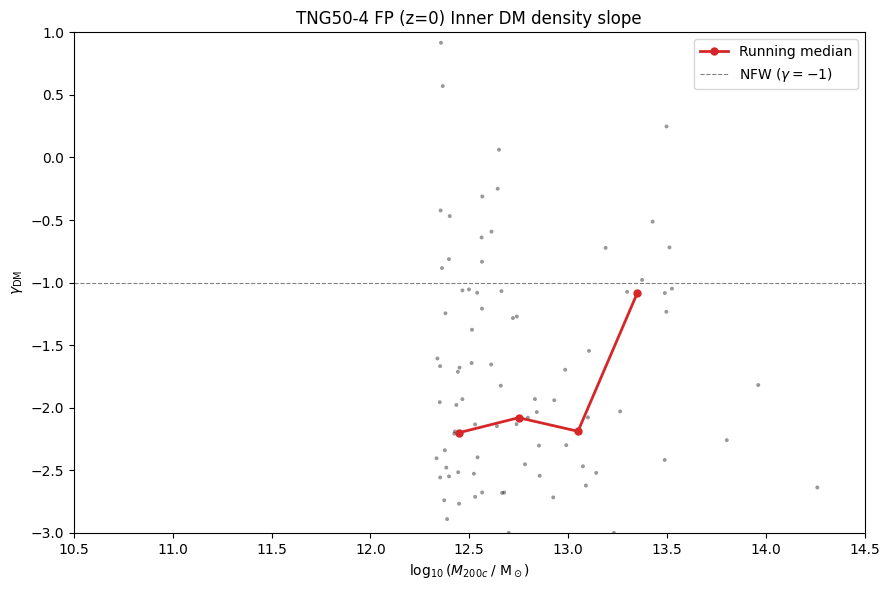

⏱ 0.1427s


In [4]:
# Figure 5 CDM-FP panel: gamma_DM vs M200c
halo_masses = m200c[halo_ids]

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    np.log10(halo_masses[valid_gamma]), gamma_dm[valid_gamma],
    s=8, alpha=0.4, c="black", edgecolors="none",
)

# Running median
log_m_bins = np.arange(10.5, 14.5, 0.3)
medians = []
bin_centres = []
for j in range(len(log_m_bins) - 1):
    in_bin = valid_gamma & (np.log10(halo_masses) >= log_m_bins[j]) & (np.log10(halo_masses) < log_m_bins[j + 1])
    if in_bin.sum() >= 5:
        medians.append(np.median(gamma_dm[in_bin]))
        bin_centres.append(0.5 * (log_m_bins[j] + log_m_bins[j + 1]))

ax.plot(bin_centres, medians, "o-", color="tab:red", lw=2, ms=5, label="Running median")

ax.axhline(-1, color="gray", ls="--", lw=0.8, label=r"NFW ($\gamma = -1$)")
ax.set_xlabel(r"$\log_{10}(M_{200c}\;/\;\mathrm{M_\odot})$")
ax.set_ylabel(r"$\gamma_{\rm DM}$")
ax.set_title("TNG50-4 FP (z=0) Inner DM density slope")
ax.legend()
ax.set_xlim(10.5, 14.5)
ax.set_ylim(-3, 1)
plt.tight_layout()
plt.savefig("figures/gamma_dm_vs_m200c_tng50-4.png", dpi=150)
plt.show()

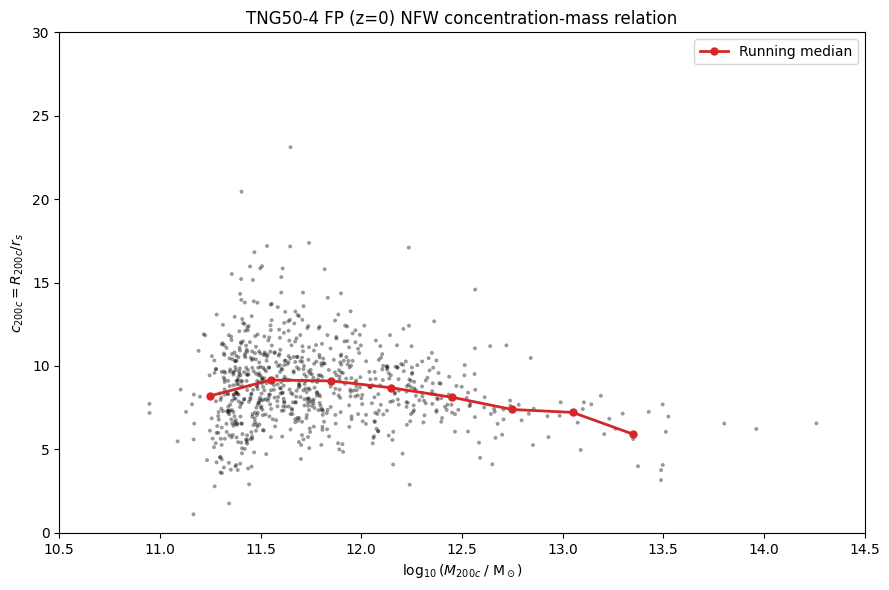

⏱ 0.1405s


In [5]:
# Bonus: concentration-mass relation from NFW fits
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    np.log10(halo_masses[valid_c200]), c200_nfw[valid_c200],
    s=8, alpha=0.4, c="black", edgecolors="none",
)

# Running median
medians_c = []
bin_centres_c = []
for j in range(len(log_m_bins) - 1):
    in_bin = valid_c200 & (np.log10(halo_masses) >= log_m_bins[j]) & (np.log10(halo_masses) < log_m_bins[j + 1])
    if in_bin.sum() >= 5:
        medians_c.append(np.median(c200_nfw[in_bin]))
        bin_centres_c.append(0.5 * (log_m_bins[j] + log_m_bins[j + 1]))

ax.plot(bin_centres_c, medians_c, "o-", color="tab:red", lw=2, ms=5, label="Running median")

ax.set_xlabel(r"$\log_{10}(M_{200c}\;/\;\mathrm{M_\odot})$")
ax.set_ylabel(r"$c_{200c} = R_{200c} / r_s$")
ax.set_title("TNG50-4 FP (z=0) NFW concentration-mass relation")
ax.legend()
ax.set_xlim(10.5, 14.5)
ax.set_ylim(0, 30)
plt.tight_layout()
plt.savefig("figures/c200_vs_m200c_tng50-4.png", dpi=150)
plt.show()